In [1]:
import astropy.units as u
from astromodels.core.model import Model
from astromodels.core.units import get_units
from astromodels.functions import Log_parabola, Log_uniform_prior, Uniform_prior
from astromodels.sources import PointSource
from astropy.coordinates import Angle, SkyCoord
from gammapy.data import DataStore
from gammapy.datasets import Datasets, SpectrumDataset
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
)
from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import LogParabolaSpectralModel, SkyModel
from regions import CircleSkyRegion
from threeML.classicMLE.joint_likelihood import JointLikelihood
from threeML import *
from threeML.data_list import DataList

from gammapy_plugin.converter import AstromodelConverter
from gammapy_plugin.GammapyLike import GammapyLike
from gammapy_plugin.test.utils import get_close

#get_units().energy = u.TeV

13:23:43 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=264813;file:///home/tobi/bin/miniconda3/envs/docs_env/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=480994;file:///home/tobi/bin/miniconda3/envs/docs_env/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#45\45]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=805950;file:///home/tobi/bin/miniconda3/envs/docs_env/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=434153;file:///home/tobi/bin/miniconda3/envs/docs_env/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#67\67]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=924724;file:///home/tobi/bin/miniconda3/envs/docs_env/lib/python3.11/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=3056;file:///home/tobi/bin/miniconda3/envs/docs_env/lib/python3.11/site-packages/astromodels/functions/functions_1D/absorption.py#34\34]8;;\
                  available                                                                                        

13:23:44 INFO      Starting 3ML!                                                                     ]8;id=739826;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=445835;file:///home/tobi/sw/threeML/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=844896;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=698460;file:///home/tobi/sw/threeML/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=105845;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=326850;file:///home/tobi/sw/threeML/threeML/__init__.py#136\136]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=298547;file:///home/tobi/sw/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=119303;file:///home/tobi/sw/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=517262;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=865498;file:///home/tobi/sw/threeML/threeML/__init__.py#345\345]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=702288;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=239881;file:///home/tobi/sw/threeML/threeML/__init__.py#345\345]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=712353;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=170695;file:///home/tobi/sw/threeML/threeML/__init__.py#345\345]8;;\
                  performances in 3ML                                                                              

In [2]:
datastore = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1/")
obs_ids = [23523, 23526, 23559, 23592]
observations = datastore.get_observations(obs_ids)

In [3]:
target_position = SkyCoord(ra=83.63, dec=22.01, unit="deg", frame="icrs")

on_region_radius = Angle("0.11 deg")
on_region = CircleSkyRegion(
    center=target_position.galactic, radius=on_region_radius
)
exclusion_region = CircleSkyRegion(
    center=SkyCoord(183.604, -8.708, unit="deg", frame="galactic"),
    radius=0.5 * u.deg,
)

skydir = target_position.galactic
geom = WcsGeom.create(
    npix=(250, 250), binsz=0.02, skydir=skydir, proj="TAN", frame="galactic"
)

exclusion_mask = ~geom.region_mask([exclusion_region])
energy_axis = MapAxis.from_energy_bounds(
    0.5, 40, nbin=10, per_decade=True, unit="TeV", name="energy"
)
energy_axis_true = MapAxis.from_energy_bounds(
    0.1, 100, nbin=20, per_decade=True, unit="TeV", name="energy_true"
)

geom = RegionGeom.create(region=on_region, axes=[energy_axis])
dataset_empty = SpectrumDataset.create(geom=geom, energy_axis_true=energy_axis_true)

dataset_maker = SpectrumDatasetMaker(
    containment_correction=True, selection=["counts", "exposure", "edisp"]
)
bkg_maker = ReflectedRegionsBackgroundMaker(exclusion_mask=exclusion_mask)
safe_mask_maker = SafeMaskMaker(methods=["aeff-max"], aeff_percent=10)
datasets = Datasets()

for obs_id, observation in zip(obs_ids, observations):
    dataset = dataset_maker.run(dataset_empty.copy(name=str(obs_id)), observation)
    dataset_on_off = bkg_maker.run(dataset, observation)
    dataset_on_off = safe_mask_maker.run(dataset_on_off, observation)
    datasets.append(dataset_on_off)
datasets_copy = datasets.copy()

logp = Log_parabola()
ps = PointSource(
    source_name="crab",
    ra=target_position.ra.deg,
    dec=target_position.dec.deg,
    spectral_shape=logp,
)
logp.K.prior = Log_uniform_prior(lower_bound=1e-13, upper_bound=1e-9)
logp.K = 1e-11*u.Unit("TeV-1 cm-2 s-1")
logp.piv = 1*u.TeV
logp.piv.free = False
logp.alpha.prior = Uniform_prior(lower_bound=-3, upper_bound=-1)
logp.alpha = -2
logp.beta.prior = Uniform_prior(lower_bound=0, upper_bound=2)
logp.beta = 1


model = Model(ps)
conv = AstromodelConverter(model, frame="galactic")
gl = GammapyLike("hess", sources="crab")
gl.set_datasets(datasets)
gl.set_model(model, converted_model=conv)

#ba = BayesianAnalysis(model, DataList(gl))
#ba.set_sampler("dynesty_dynamic")
#ba.sampler.setup()#(resume=False,verbose = False)
#ba.sample()
jl = JointLikelihood(model,DataList(gl))
jl.fit()
#res = ba.results
res = jl.results

Only Single Spectral Component Models currently supported


13:23:47 INFO      set the minimizer to minuit                                              ]8;id=25606;file:///home/tobi/sw/threeML/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=907806;file:///home/tobi/sw/threeML/threeML/classicMLE/joint_likelihood.py#994\994]8;;\


WARNING RuntimeWarning: overflow encountered in reduce


WARNING RuntimeWarning: overflow encountered in reduce


WARNING RuntimeWarning: overflow encountered in reduce


WARNING RuntimeWarning: overflow encountered in reduce



Best fit values:

,result,unit
parameter,,
crab.spectrum.main.Log_parabola.K,(4.36 -0.22 +0.23) x 10^-20,1 / (keV s cm2)
crab.spectrum.main.Log_parabola.alpha,-2.39 +/- 0.14,
crab.spectrum.main.Log_parabola.beta,(1.6 +/- 0.8) x 10^-1,


...

1.00,-0.10,0.17
-0.10,1.00,0.85
0.17,0.85,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
hess,44.416458
total,44.416458


Values of statistical measures:

,statistical measures
AIC,95.148706
BIC,101.978996


In [4]:
import numpy as np
import matplotlib.pyplot as plt
e = np.geomspace(1e-1,1e2,1000)*u.TeV

In [5]:
def mohrmann_weird_spec(E, N0, E0, gamma1,gamma2, Ebreak, beta):
    return N0*np.power(E/E0,-gamma1)*np.power(1+np.power(E/Ebreak,(gamma2-gamma1)/beta),-beta)

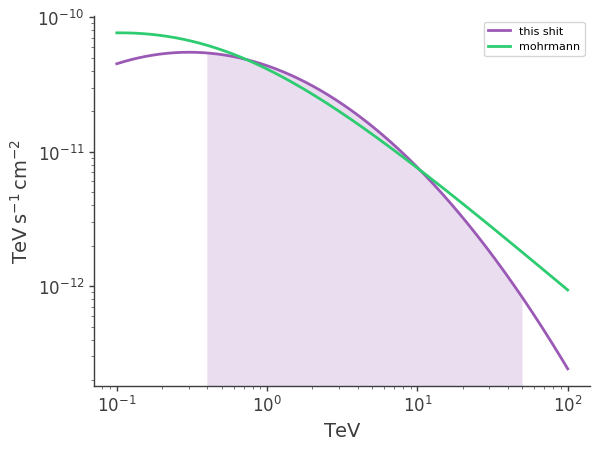

In [15]:
plt.plot(e,e**2*ps(e).to("TeV-1 cm-2 s-1"),label="this shit")
plt.plot(e,e**2*mohrmann_weird_spec(e,3.35*1e-10*u.Unit("TeV-1 s-1 cm-2"),1.0*u.TeV,1.61,2.95,0.33*u.TeV, 1.73),label = "mohrmann")
plt.fill_between(np.geomspace(0.4*u.TeV,50*u.TeV,100),np.geomspace(0.4*u.TeV,50*u.TeV,100)**2*ps(np.geomspace(0.4,50,100)*u.TeV).to("TeV -1 cm-2 s-1"),alpha=0.2)
#plt.ylim(3*10e-15,3*10e-11)
plt.xscale("log")
plt.yscale("log")
plt.legend()

TeV
1 / (TeV s cm2)


processing MLE analyses:   0%|                                                                                …

Transformed to 1.0 1 / (keV s cm2)
Calculating the conversion
The conversion 1 / (TeV s cm2)


Propagating errors:   0%|                                                                                   | …

999999999.9999999


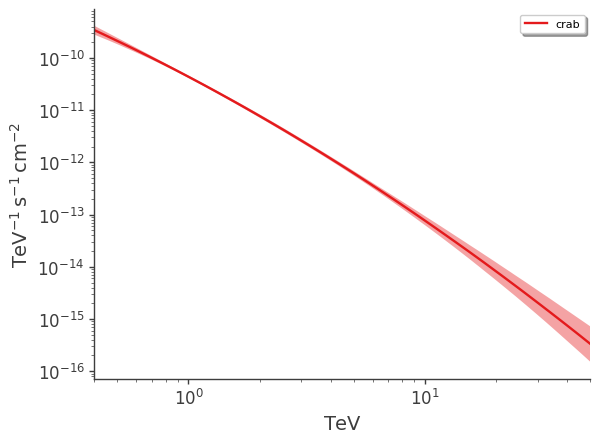

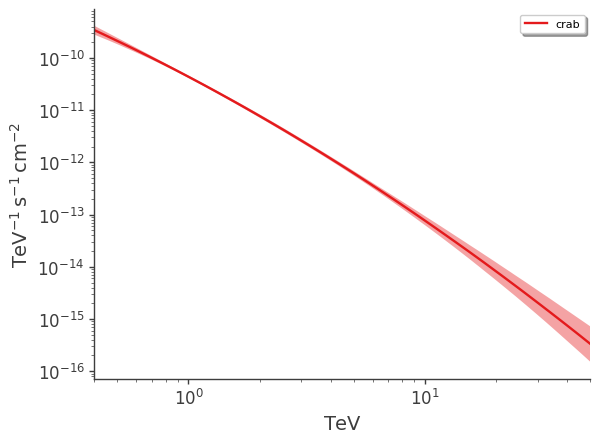

In [7]:
plot_spectra(res,energy_unit = u.TeV,flux_unit=u.Unit("TeV-1 cm-2 s-1"),ene_min = 0.4,ene_max = 50)

In [8]:
plot_spectra?

Signature: plot_spectra(*analysis_results, **kwargs) -> matplotlib.figure.Figure
Docstring:
Plotting routine for fitted point source spectra.

:param analysis_results: fitted JointLikelihood or BayesianAnalysis
    objects
:param sources_to_use: (optional) list of PointSource string names
    to plot from the analysis
:param energy_unit: (optional) astropy energy unit in string form
    (can also be frequency)
:param flux_unit: (optional) astropy flux unit in string form
:param confidence_level: (optional) confidence level to use
    (default: 0.68)
:param ene_min: (optional) minimum energy to plot
:param ene_max: (optional) maximum energy to plot
:param num_ene: (optional) number of energies to plot
:param use_components: (optional) True or False to plot the spectral
    components
:param components_to_use: (optional) list of string names of the
    components to plot: including 'total' will also plot the total
    spectrum
:param sum_sources: (optional) sum all the MLE and Bayesian s

In [9]:
dir(res)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_analysis_type',
 '_covariance_matrix',
 '_free_parameters',
 '_get_correlation_matrix',
 '_get_results_table',
 '_get_statistic_frame',
 '_n_free_parameters',
 '_optimal_statistic_values',
 '_optimized_model',
 '_samples_transposed',
 '_statistical_measures',
 '_values',
 'analysis_type',
 'covariance_matrix',
 'display',
 'estimate_covariance_matrix',
 'get_correlation_matrix',
 'get_data_frame',
 'get_equal_tailed_interval',
 'get_flux',
 'get_point_source_flux',
 'get_statistic_frame',
 'get_statistic_measure_frame',
 'get_variates',
 'optimal_statistic_values',
 'optimized_model',
 'propagate',
 'sa

In [10]:
res.plot_chains()

AttributeError: 'MLEResults' object has no attribute 'plot_chains'

In [ ]:
res.write_to("crappycrabby.fits",overwrite=True)

In [ ]:
from astropy.io import fits as fits

In [ ]:
with fits.open("crappycrabby.fits") as f:
    print(*[f"{x}\n" for x in f[1].header["MODEL"].split("_NEWLINE_")])

In [ ]:
from threeML import load_analysis_results
from astromodels import *
#get_units().energy = u.keV
#get_units().to_dict()

In [ ]:
ar = load_analysis_results("crappycrabby.fits")

In [ ]:
ar

In [ ]:
plot_spectra(ar,ene_min = 1e8, ene_max = 1e10)

In [ ]:
ar.optimized_model.crab

In [ ]:
threeML_config.model_plot.point_source_plot["flux_unit"] = "1/(TeV s cm2)"

In [ ]:
threeML_config.model_plot.point_source_plot["ene_unit"] = "TeV"

In [ ]:
import numpy as np
np.linspace(1*u.TeV,10*u.TeV,10)